In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats

In [2]:
sns.load_dataset('titanic')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
df = sns.load_dataset('titanic')
df = df.dropna(subset = ['age', 'fare'])
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
n_f = ['age', 'fare']
desc_st = df[n_f].agg(['mean', 'median', 'std'])
sk = df[n_f].skew()
kurt = df[n_f].kurtosis()
desc_st, sk, kurt

(              age       fare
 mean    29.699118  34.694514
 median  28.000000  15.741700
 std     14.526497  52.918930,
 age     0.389108
 fare    4.653630
 dtype: float64,
 age      0.178274
 fare    30.924249
 dtype: float64)

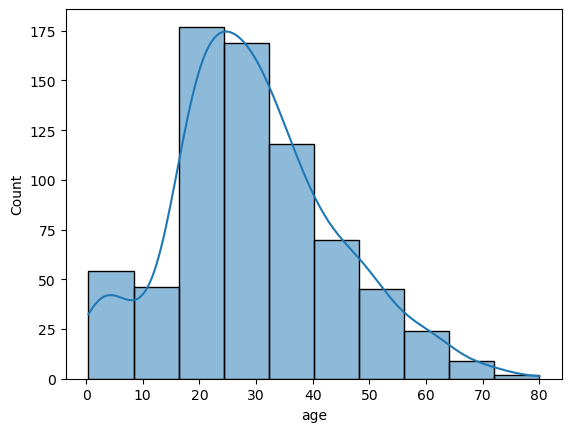

In [5]:
sns.histplot(df['age'], bins = 10, kde = True);

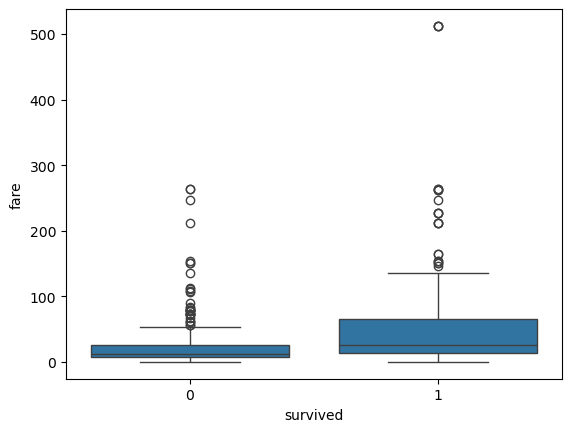

In [31]:
sns.boxplot(x = df['survived'], y = df['fare']);

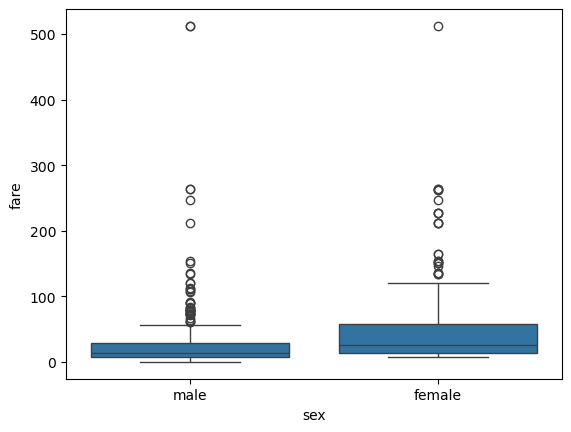

In [7]:
sns.boxplot(x = df['sex'], y = df['fare']);

In [8]:
#inference
survived = df[df['survived'] == 1]['age']
not_survived = df[df['survived'] == 0]['age']

In [9]:
df[n_f].describe()['age']['mean']

29.69911764705882

In [10]:
desc_st['age']['mean']

29.69911764705882

In [11]:
desc_st

,age,fare
mean,29.699118,34.694514
median,28.000000,15.741700
std,14.526497,52.918930


In [12]:
n = len(df['age'])
#age skew
sk_num = (sum((x - desc_st['age']['mean']) ** 3 for x in df['age']) / n)
sk_den = desc_st['age']['std'] ** 3
sk = sk_num / sk_den

#age kurt
kurt_num = (sum((x - desc_st['age']['mean']) ** 4 for x in df['age']) / n)
kurt_den = desc_st['age']['std'] ** 4
kurt = kurt_num / kurt_den

sk, kurt

(0.3874744021759851, 3.159767055046596)

In [13]:
n = len(df['fare'])
#age skew
sk_num = (sum((x - desc_st['fare']['mean']) ** 3 for x in df['fare']) / n)
sk_den = desc_st['fare']['std'] ** 3
sk = sk_num / sk_den

#age kurt
kurt_num = (sum((x - desc_st['fare']['mean']) ** 4 for x in df['fare']) / n)
kurt_den = desc_st['fare']['std'] ** 4
kurt = kurt_num / kurt_den

sk, kurt

(4.634095555888942, 33.605394351916715)

In [14]:
survived.var()

223.53096523207253

In [15]:
import statistics
statistics.variance(survived)

223.53096523207256

In [17]:
not_survived.var()

200.84869836968645

In [18]:
survived = df[df['survived'] == 1]['age']
did__not = df[df['survived'] == 0]['age']
t_stat, p_value = stats.ttest_ind(survived, did__not, equal_var = False)
t_stat, p_value

(-2.0460301043939704, 0.04118965162586639)

In [19]:
survived = df[df['survived'] == 1]['age']
did__not = df[df['survived'] == 0]['age']
t_stat, p_value = stats.ttest_ind(survevaluation matrix, usage of hypothesis in ml, f1 score, Bayes theorem, conditional probability, z, t, anova, chi2 explain all theseived, did__not, equal_var = True)
t_stat, p_value

(-2.06668694625381, 0.03912465401348249)

In [20]:
survived = df[df['survived'] == 1]['age']
did__not = df[df['survived'] == 0]['age']
t_stat, p_value = stats.ttest_ind(survived, did__not)
t_stat, p_value

(-2.06668694625381, 0.03912465401348249)

In [21]:
contingency = pd.crosstab(df['sex'], df['survived'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
'chi',chi2, 'p', p, 'dof', dof, 'ex', expected

('chi',
 205.02582752855906,
 'p',
 1.6716678441395297e-46,
 'dof',
 1,
 'ex',
 array([[154.99159664, 106.00840336],
        [269.00840336, 183.99159664]]))

In [25]:
import numpy as np
co = pd.crosstab(df['sex'], df['survived'])
ch, pv, do, ex = stats.chi2_contingency(co)
ch, pv, do, ex

(205.02582752855906,
 1.6716678441395297e-46,
 1,
 array([[154.99159664, 106.00840336],
        [269.00840336, 183.99159664]]))

In [29]:
df['age'].std()

14.526497332334042